#Worksheet 05
##Implement an End to End CNN Model for Image Classification Task
###Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

###Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

    • Get the list of class directories from the train folder.

    • Select one image randomly from each class.

    • Display the images in a grid format with two rows using matplotlib.

In [2]:
import os
print(os.listdir('/content'))

['.config', 'FruitinAmazon', 'FruitinAmazon.zip', 'sample_data']


In [3]:

import zipfile

zip_path = "/content/FruitinAmazon.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
print(os.listdir('/content'))

['.config', 'FruitinAmazon', 'FruitinAmazon.zip', 'sample_data']


In [7]:
extract_path = "/content/FruitinAmazon"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("ZIP extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [10]:

def find_folder(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

train_dir = find_folder(extract_path, "train")
test_dir = find_folder(extract_path, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /content/FruitinAmazon/train
Test folder: /content/FruitinAmazon/test


Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


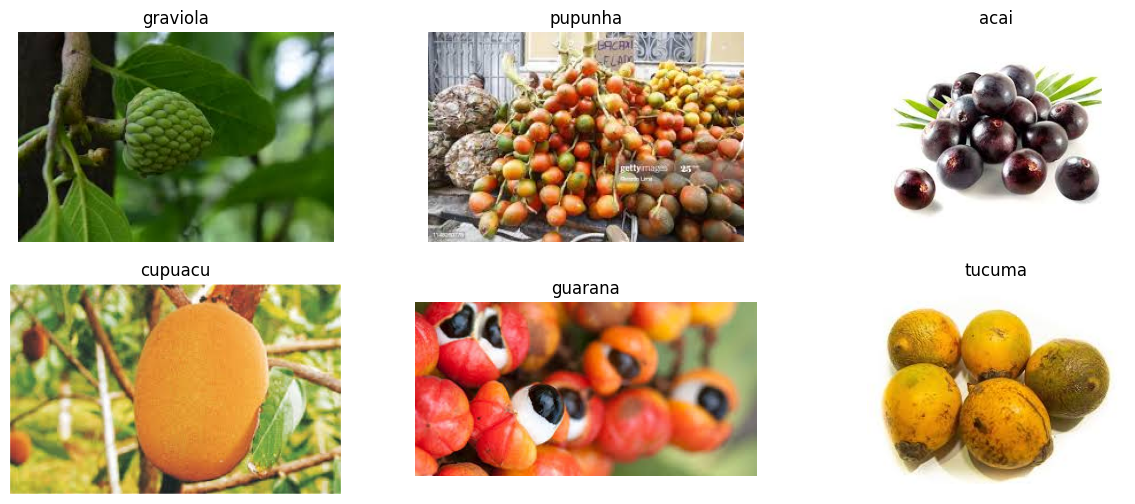

In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

plt.figure(figsize=(15,6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))

    plt.subplot(2, (len(classes)+1)//2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

    • Hint:

    -Iterate through each class subdirectory and check if each image is valid.

    -Use the Image.open() function to attempt to load each image.

    -If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".

     -Maintain a list of all corrupted image paths for reporting.
    • Expected Output: No corrupted images found



In [14]:

corrupted_images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In this section, we will load and preprocess image data from a directory using the image dataset from directory function in Keras. This function is used to load images from a directory structure where subdirectories represent different classes. We will also apply basic preprocessing, including resizing and batching and normalization of images. The same function can be used to load train and validation data.

In [15]:

# Define image size and batch size
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2    # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)     # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with
###Follow the following Structure and Hyper - parameters:
##Convolutional Architecture:

• Convolutional Layer 1:

    Filter Size (F): (3, 3)

    Number of Filters (k): 32

    Padding (P): same

    Stride (s): 1

• Activation Layer: ReLU activation


• Pooling Layer 1: Max pooling

    Filter Size (F): (2, 2)

    Stride (s): 2

• Convolutional Layer 2:

    Filter Size (F): (3, 3)

    Number of Filters (k): 32

    Padding (P): same

    Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

    Filter Size (F): (2, 2)

    Stride (s): 2

#Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

    Number of Neurons: 64

    Number of Neurons: 128

• Output Layer:

    Number of Neurons: num classes (number of output classes)

In [16]:

num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
##Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

#Task 4: Train the Model
Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [17]:
# Define image size and batch size
img_height, img_width = 128, 128
batch_size = 16
validation_split = 0.2

# Normalize pixel values
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Optional performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Build model
num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, earlystop]
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1392 - loss: 1.8762
Epoch 1: val_loss improved from None to 1.77847, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 0.1389 - loss: 1.8706 - val_accuracy: 0.0000e+00 - val_loss: 1.7785
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3090 - loss: 1.7333
Epoch 2: val_loss improved from 1.77847 to 1.63106, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.3056 - loss: 1.6929 - val_accuracy: 0.4444 - val_loss: 1.6311
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.3788 - loss: 1.5598
Epoch 3: val_loss improved from 1.63106 to 1.43090, saving model to best_model.keras

Epoch 3: finishe

#Task 6: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.

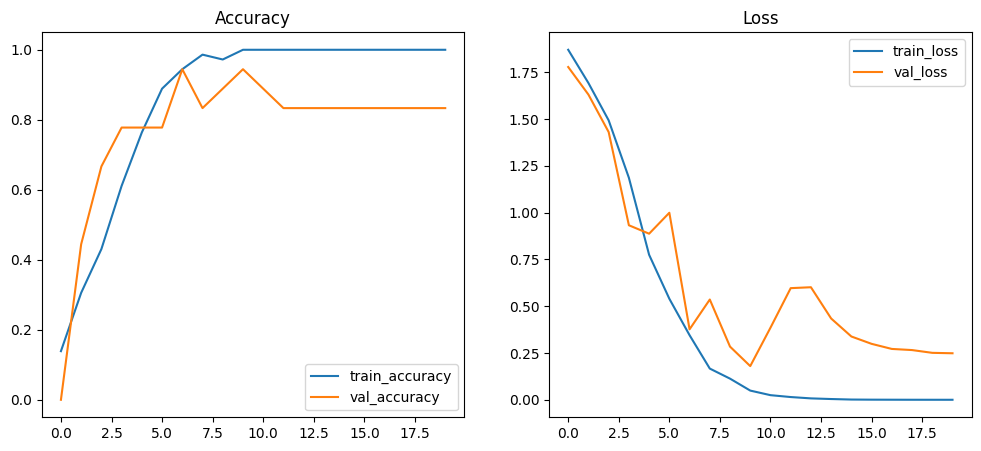

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.show()

In [19]:

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [20]:


test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7667 - loss: 0.8623
Test Loss: 0.862338662147522
Test Accuracy: 0.7666666507720947


##Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [22]:
from tensorflow.keras.models import load_model

# Save the trained model in .h5 format
model.save("fruit_cnn_model.h5")
print("Model saved as fruit_cnn_model.h5")

# Load the saved model
loaded_model = load_model("fruit_cnn_model.h5")
print("Model loaded successfully")

# Evaluate the loaded model on test dataset
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_test_loss)
print("Loaded Model Test Accuracy:", loaded_test_acc)

Model saved as fruit_cnn_model.h5
Model loaded successfully
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7667 - loss: 0.8623
Loaded Model Test Loss: 0.862338662147522
Loaded Model Test Accuracy: 0.7666666507720947


##Task 7: Predictions and Classification Report
###Making Predictions
• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification

Report of your Model Performance.

In [24]:
best_model = load_model('best_model.keras')
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(y_true, y_pred, target_names=classes)
print(report)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step
              precision    recall  f1-score   support

    graviola       0.71      1.00      0.83         5
     pupunha       0.83      1.00      0.91         5
        acai       1.00      1.00      1.00         5
     cupuacu       1.00      0.20      0.33         5
     guarana       0.62      1.00      0.77         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.77        30
   macro avg       0.81      0.77      0.72        30
weighted avg       0.81      0.77      0.72        30

